# 1 Architecture

**Elasticsearch:** Core distributed System

**Kibana:** Monitoring & Dev Tools

**Python:** Preprocessing, Embeddings, Semantic Search and RAG

**Dataset:** arXiv CS Subset (Titles + Abstracts)


# 2 Dowloading Data

The data is downloaded from Kaggle and stored in location *data/arxiv-metadata-oai-snapshot.json*

# 3 Preprocessing Data

- We first filtered the data for only the CS papers using the script *filter_cs.py* resulting in the final dataset in *arxiv-cs.csv* which has:
    - 846,757 data instances
    - 1.08 GB
- We then preprocess the data using the script *prepare_data.py*. The following things were done:
    - Normalize the data
    - Filtering only the relevant columns
    - We then generate json of this in text form in *arxiv_text_bulk.ndjson*
    - After this we generate embeddings for all of the data *(MiniLM-L6-v2, dim=384)* and store them as vectors in a json as *arxiv_vector_bulk.ndjson*

# 4 Building Cluster

- We build the distributed cluster using elasticsearch with the following configuration:
    - 3 shards
    - 1 replica
- We define this in: *docker-compose.yml*
- We build the cluster using: *docker compose up -d*
- We can verify the creation using: *curl http://localhost:9200*

# 5 Populating Cluster

## Creating Elasticsearch Indices

**Text Indices (BM25)**

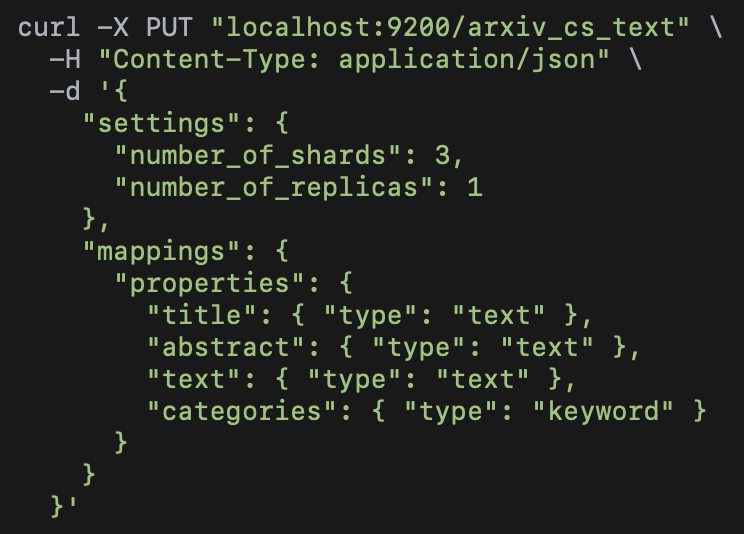

**Vector Indeices (dense vector + ANN)**

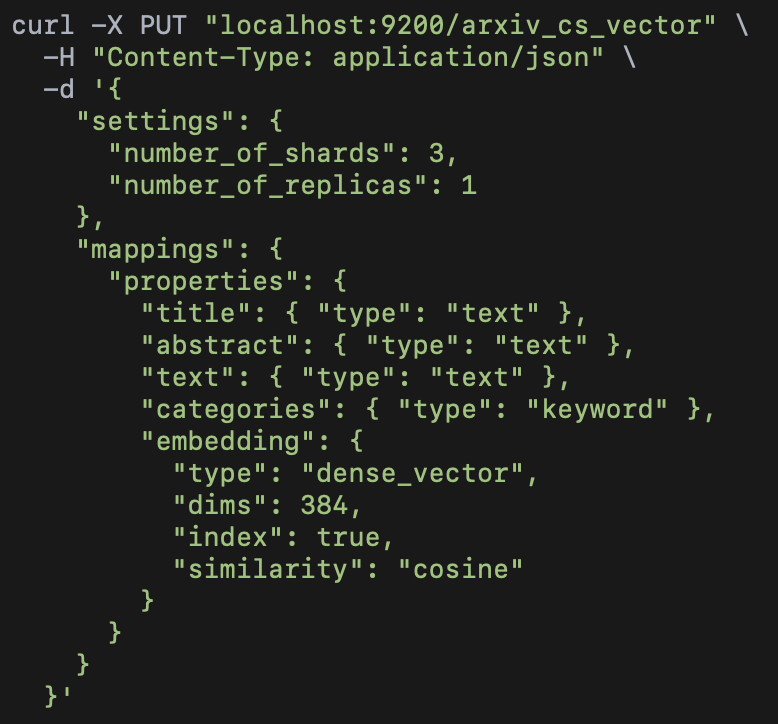

## Loading Data into the Indices 

We split the data and uploade them to reduce the upload bulk of the files:

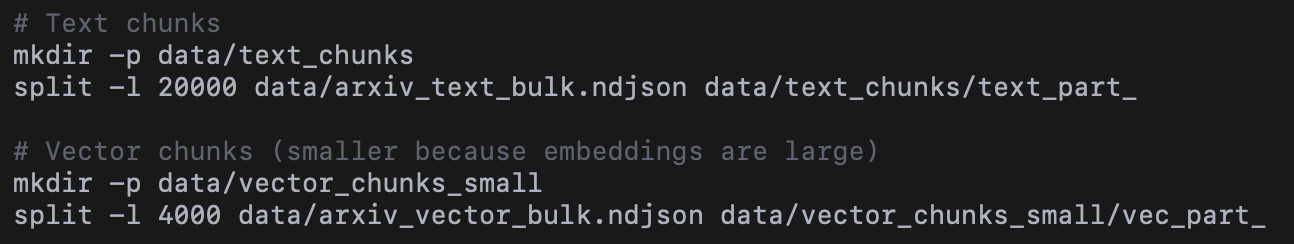

**Bulk Load Text Index**

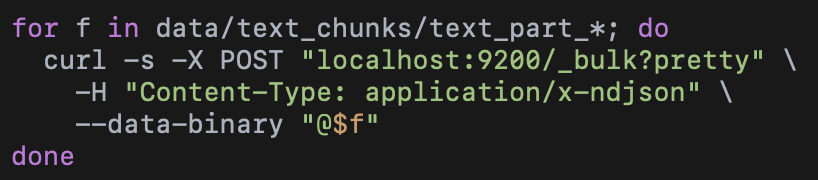

**Bulk Load Vector Index**

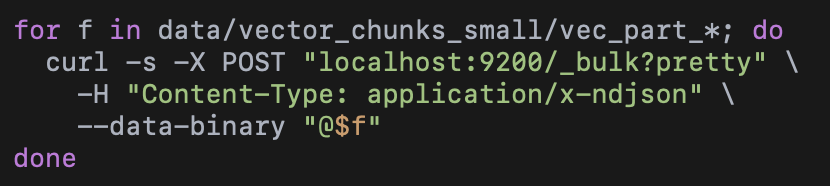

**Verify Document Counts**

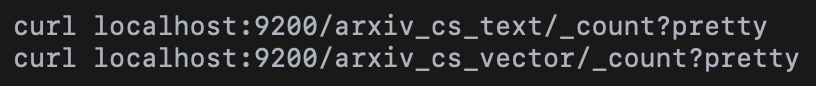

# 6 Semantic Search

Elasticsearch's ANN is exposed via *script_score* using cosine similarity.

# 7 Snapshot/Restore

Create a snapshot directory:

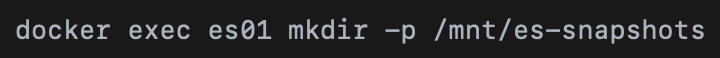

Create the snapshot repository:

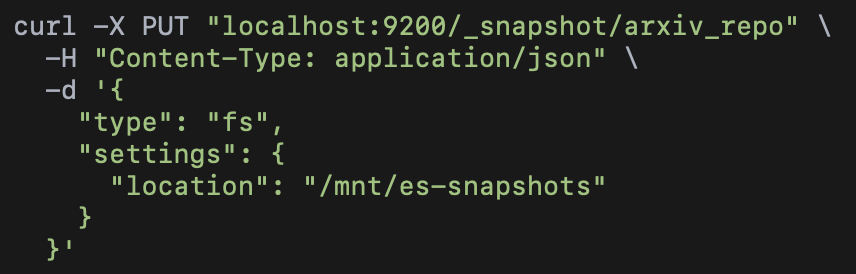

Taking a snapshot:

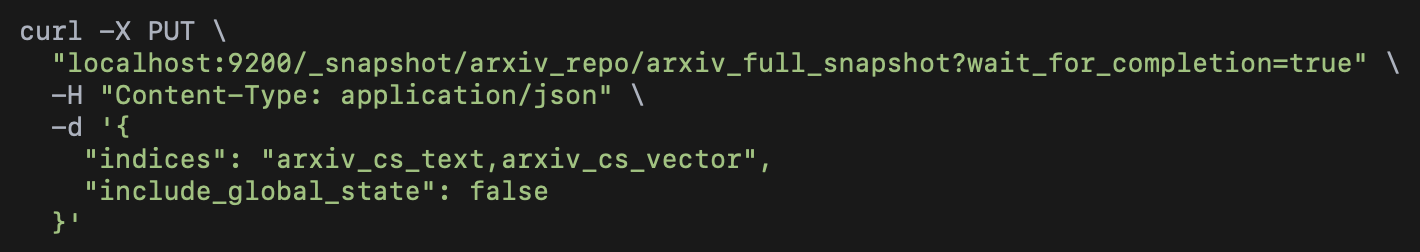

Listing snapshots:

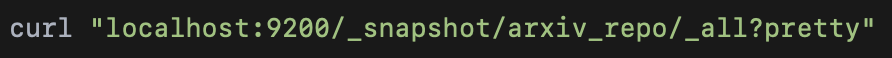